<a href="https://colab.research.google.com/github/malakatifang/IDS_ML/blob/main/notebook/ids_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# Définition de la liste des colonnes (43 colonnes au total)
columns = ["duration","protocol_type","service","flag","src_bytes","dst_bytes",
           "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
           "num_compromised","root_shell","su_attempted","num_root",
           "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
           "is_host_login","is_guest_login","count","srv_count","serror_rate",
           "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
           "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
           "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
           "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
           "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"]
#label : Elle contient la "réponse", c'est-à-dire si la connexion est normal ou s'il s'agit d'une attaque spécifique (comme neptune, satan, etc.).

#difficulty : Une note interne au dataset NSL-KDD évaluant la difficulté pour un modèle à classifier cette ligne particulière.

# Chargement de données
train = pd.read_csv("KDDTrain+.txt", names=columns, header=None)
test = pd.read_csv("KDDTest+.txt", names=columns, header=None)

In [3]:
# Ciblez explicitement la colonne label pour y, et supprimez label et difficulty pour X
#X:Features==tableau de prédiction
X = train.drop(columns=["label", "difficulty"])
#y:Target==variable que le modèle doit apprendre à deviner
y = train["label"]

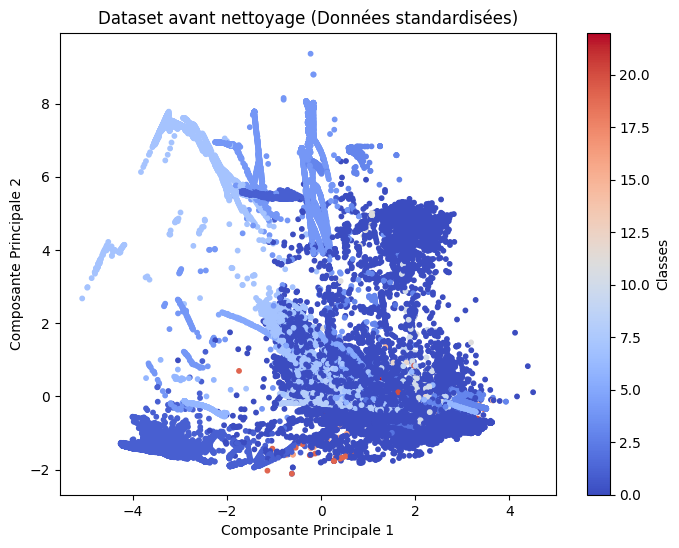

In [4]:
#visualisation de donnee
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Isoler les données numériques
X_numeric = X.select_dtypes(include=['number'])

# 2. Centrer et réduire les données (Standardisation)
X_scaled = StandardScaler().fit_transform(X_numeric)

# 3. Appliquer la PCA sur les données standardisées
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Affichage du graphique corrigé
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=pd.factorize(y)[0], cmap='coolwarm', s=10)
plt.title("Dataset avant nettoyage (Données standardisées)")
plt.xlabel("Composante Principale 1")
plt.ylabel("Composante Principale 2")
plt.colorbar(label='Classes')
plt.show()

In [5]:
# Compte le nombre de valeurs manquantes dans tout le dataset
print(train.isnull().sum().sum())

0


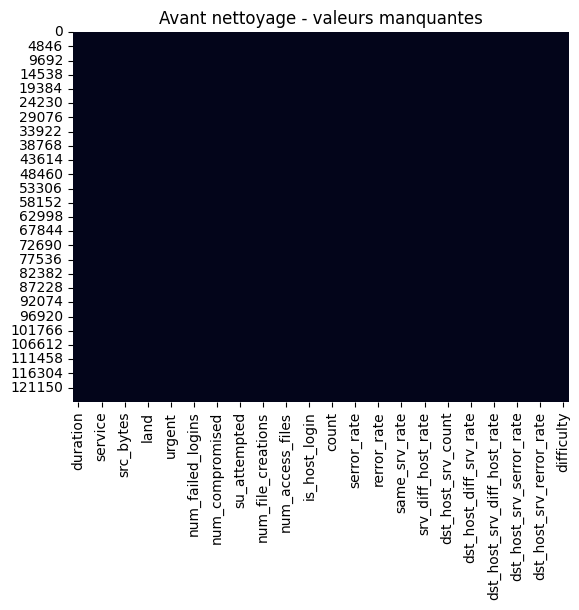

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
# visualiser les valeurs manquantes
plt.figure()
sns.heatmap(train.isnull(), cbar=False)
plt.title("Avant nettoyage - valeurs manquantes")
plt.show()

In [7]:
# Nettoyage
#eviter la tricherie du modele pendant l'apprentissage
train.drop("difficulty", axis=1, inplace=True, errors='ignore')
test.drop("difficulty", axis=1, inplace=True, errors='ignore')

In [8]:
# la suppression des ligne avec des valeurs manquantes
train = train.dropna()

In [9]:
# Encodage des variables catégorielles textuelles en colonnes binaires (0 ou 1)
train = pd.get_dummies(train, columns=["protocol_type", "service", "flag"])
test = pd.get_dummies(test, columns=["protocol_type", "service", "flag"])

In [10]:
# Aligner le train et le test pour s'assurer qu'ils ont exactement les mêmes colonnes après get_dummies
train, test = train.align(test, join='left', axis=1, fill_value=0)

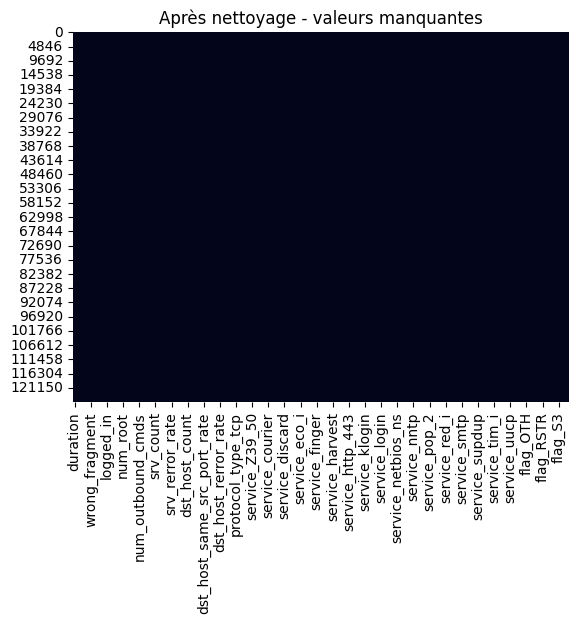

In [11]:
# Visualisation après nettoyage
plt.figure()
sns.heatmap(train.isnull(), cbar=False)
plt.title("Après nettoyage - valeurs manquantes")
plt.show()

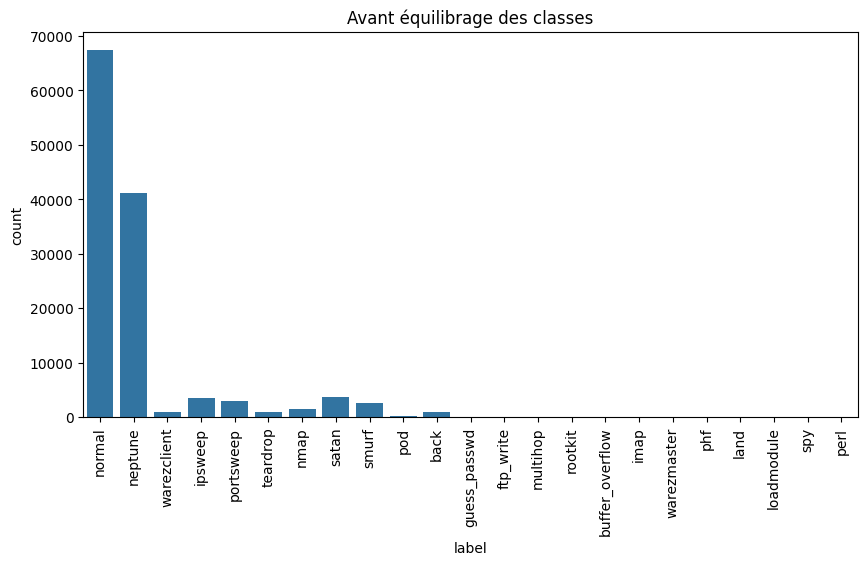

In [12]:
# Distribution avant équilibrage
plt.figure(figsize=(10, 5))
sns.countplot(x=train["label"])
plt.xticks(rotation=90)
plt.title("Avant équilibrage des classes")
plt.show()

In [13]:
# Séparation des features et de la cible à partir du train nettoyé
X = train.drop("label", axis=1).astype(float) # Conversion explicite en float pour éviter les bugs SMOTE
y = train["label"]


In [14]:
#equilibrage
# Utilisation obligatoire de k_neighbors=1 ou 2 à cause des classes ultra-rares (ex: 'spy')
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42, k_neighbors=1)
X_res, y_res = smote.fit_resample(X, y)

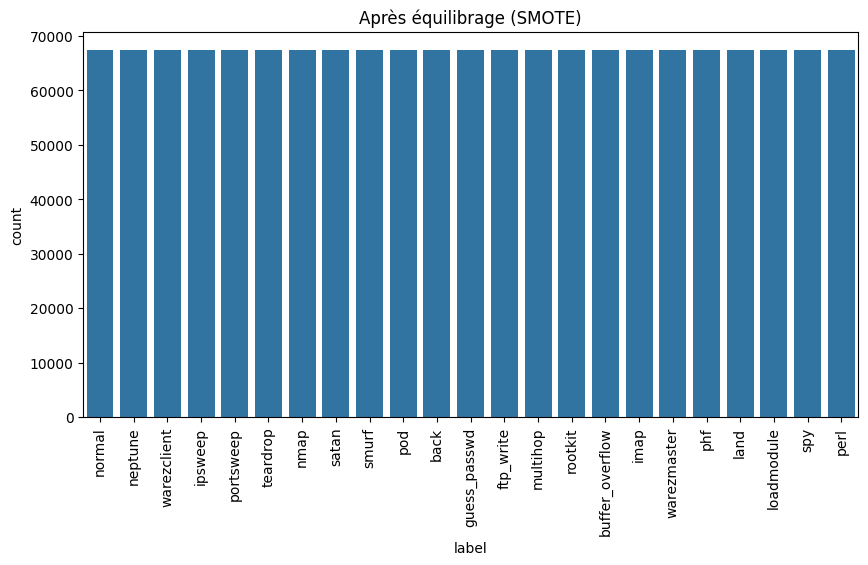

In [15]:
# Distribution après équilibrage
plt.figure(figsize=(10, 5))
sns.countplot(x=y_res)
plt.xticks(rotation=90)
plt.title("Après équilibrage (SMOTE)")
plt.show()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
## Division des données équilibrées : 80% pour l'entraînement et 20% pour la validation intermédiaire
# Split
X_train, X_val, y_train, y_val = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

In [ ]:
#  REGRESSION LOGISTIQUE
from sklearn.linear_model import LogisticRegression
# 1. Initialisation du modèle avec 1000 itérations pour assurer la convergence des calculs
model_lr = LogisticRegression(max_iter=1000)

# 2. Entraînement du modèle sur les données d'apprentissage équilibrées (80%)
model_lr.fit(X_train, y_train)

# 3. Prédiction sur les données de validation (l'examen blanc de 20%)
y_pred_lr = model_lr.predict(X_val)

In [ ]:
print("--- Régression Logistique ---")
print("Accuracy:", accuracy_score(y_val, y_pred_lr))
print(classification_report(y_val, y_pred_lr))

In [ ]:
 # Matrice de confusion
cm_lr = confusion_matrix(y_val, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp_lr.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [ ]:
# Courbe ROC (Adaptée pour le multiclasse : Normal vs Reste)
y_val_binary = (y_val != 'normal').astype(int)

# Trouve la position de la classe 'normal' dans la liste des classes du modèle
normal_idx = list(model_lr.classes_).index('normal')

# Calcule la probabilité que ce soit une attaque
y_prob_lr = 1 - model_lr.predict_proba(X_val)[:, normal_idx]

fpr, tpr, _ = roc_curve(y_val_binary, y_prob_lr)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

In [ ]:
# RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_val)

In [ ]:
print("--- Random Forest ---")
print("Accuracy:", accuracy_score(y_val, y_pred_rf))
print(classification_report(y_val, y_pred_rf))

In [ ]:
# Matrice de confusion
cm_rf = confusion_matrix(y_val, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [ ]:
# ROC Random Forest
normal_idx_rf = list(model_rf.classes_).index('normal')
y_prob_rf = 1 - model_rf.predict_proba(X_val)[:, normal_idx_rf]
fpr, tpr, _ = roc_curve(y_val_binary, y_prob_rf)
roc_auc_rf = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc_rf:.2f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

In [ ]:
# DECISION TREE
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_val)

In [ ]:
print("--- Decision Tree ---")
print("Accuracy:", accuracy_score(y_val, y_pred_dt))
print(classification_report(y_val, y_pred_dt))

In [ ]:
# Matrice de confusion
cm_dt = confusion_matrix(y_val, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp_dt.plot(cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

In [ ]:
# ROC Decision Tree
normal_idx_dt = list(model_dt.classes_).index('normal')
y_prob_dt = 1 - model_dt.predict_proba(X_val)[:, normal_idx_dt]
fpr, tpr, _ = roc_curve(y_val_binary, y_prob_dt)
roc_auc_dt = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc_dt:.2f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()

In [ ]:
# Prédictions sur le jeu de test
new_data = test.drop("label", axis=1).astype(float) # Conversion obligatoire en float

predictions = model_rf.predict(new_data)
print("10 premières prédictions sur le set de test :")
print(predictions[:10])

In [ ]:
# Rapport de comparaison final
models = {
    "Logistic Regression": model_lr,
    "Decision Tree": model_dt,
    "Random Forest": model_rf
}

print("\n======= COMPARAISON DES MODELES =======")
for name, model in models.items():
    y_pred = model.predict(X_val)
    print(f"\n Rapports de performance pour : {name}")
    print(classification_report(y_val, y_pred))